In [4]:
import torch
from src.mssp import MSSP
import matplotlib.pyplot as plt
import pandas as pd
import time

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
RANDOM_SEED = 42

In [5]:
data = pd.read_csv("bikes_data.csv")

In [6]:
data.head()

,Temp,Atemp,Hum,Windspeed,Casual,Registered,Cntlag,Cnt
0,0.200000,0.212122,0.590436,0.160296,120.0,1229.0,5.832896,5.458242
1,0.226957,0.229270,0.436958,0.186900,108.0,1454.0,5.458242,5.335675
2,0.204348,0.233209,0.518262,0.089565,82.0,1518.0,5.335675,5.315381
3,0.196522,0.208839,0.498697,0.168726,88.0,1518.0,5.315381,5.250001
4,0.165000,0.162254,0.535834,0.266804,148.0,1362.0,5.250001,4.857664


In [7]:
X = torch.tensor(data.drop(columns=['Cnt']).values, dtype=torch.double)
y = torch.tensor(data['Cnt'].values, dtype=torch.double)

In [8]:
n = len(X)
train_end = int(n * 0.7)
valid_end = int(n * 0.8)

X_train = X[:train_end]
X_valid = X[train_end:valid_end]
X_test = X[valid_end:]

y_train = y[:train_end]
y_valid = y[train_end:valid_end]
y_test = y[valid_end:]

In [9]:
mae_scores = []
for i in range(1, 11):
    mssp = MSSP(
        n_best=100, 
        loss_fn="mse", 
        random_seed=42, 
        epochs=i, 
        diversity_ratio=0.75, 
        pow_cross=True,
    )

    st_ft = time.time()
    mssp.fit(X_train, y_train, X_valid, y_valid)
    et_fr = time.time()
    for k in (1, 4, 16, 32):
        st_pr = time.time()
        mssp_pred = mssp.predict(X_test, top_k=k)
        et_pr = time.time()
        # Remove nans and infs for valid mask
        mask = (~mssp_pred.isnan()) & (~torch.isinf(mssp_pred))
        mae = mean_absolute_error(mssp_pred[mask], y_test[mask])
        mae_scores.append(('mssp', i, k, mae, et_fr - st_ft, et_pr - st_pr))

loss (mse): 0.02463459223508835 epoch: 0 , time: 0.26s
Best loss: 0.02463459223508835 after training for 0 epochs
loss (mse): 0.02463459223508835 epoch: 0 , time: 0.02s
loss (mse): 0.02337644435465336 epoch: 1 , time: 0.05s
Best loss: 0.02337644435465336 after training for 1 epochs
loss (mse): 0.02463459223508835 epoch: 0 , time: 0.02s
loss (mse): 0.02337644435465336 epoch: 1 , time: 0.04s
loss (mse): 0.021801624447107315 epoch: 2 , time: 0.03s
Best loss: 0.021801624447107315 after training for 2 epochs
loss (mse): 0.02463459223508835 epoch: 0 , time: 0.02s
loss (mse): 0.02337644435465336 epoch: 1 , time: 0.03s
loss (mse): 0.021801624447107315 epoch: 2 , time: 0.04s
loss (mse): 0.021013246849179268 epoch: 3 , time: 0.03s
Best loss: 0.021013246849179268 after training for 3 epochs
loss (mse): 0.02463459223508835 epoch: 0 , time: 0.02s
loss (mse): 0.02337644435465336 epoch: 1 , time: 0.04s
loss (mse): 0.021801624447107315 epoch: 2 , time: 0.04s
loss (mse): 0.021013246849179268 epoch: 3 ,

In [10]:
linreg_model = LinearRegression()
st_ft = time.time()
linreg_model.fit(X_train, y_train)
et_ft = time.time()
st_pr = time.time()
linreg_pred = torch.tensor(linreg_model.predict(X_test), dtype=torch.double)
et_pr = time.time()
mae = mean_absolute_error(linreg_pred, y_test)
mae_scores.append(("lin", 1, 1, mae, et_ft - st_ft, et_pr - st_pr))

In [11]:
data['Cntlag'].values

array([5.83289626e+00, 5.45824183e+00, 5.33567493e+00, 5.31538134e+00,
       5.25000139e+00, 4.85766450e+00, 5.15748767e+00, 5.78604226e+00,
       5.26673917e+00, 5.22829117e+00, 5.50224449e+00, 5.32225041e+00,
       5.18181977e+00, 5.27574543e+00, 5.12598900e+00, 4.93037793e+00,
       6.19367406e+00, 5.46682745e+00, 5.08940254e+00, 4.85872696e+00,
       5.31672225e+00, 5.67357327e+00, 5.64942127e+00, 3.94480083e+00,
       5.15120977e+00, 6.30772189e+00, 5.25069234e+00, 5.30981520e+00,
       5.62610272e+00, 5.21299150e+00, 5.42680358e+00, 5.32724335e+00,
       5.40870652e+00, 4.78130280e+00, 5.79092710e+00, 5.36502434e+00,
       5.19924381e+00, 5.35949437e+00, 5.26899747e+00, 5.43848294e+00,
       5.14093291e+00, 5.38812122e+00, 5.49720615e+00, 5.25905113e+00,
       5.46460770e+00, 5.46882393e+00, 5.47937596e+00, 4.72930315e+00,
       5.41442675e+00, 4.81886080e+00, 5.58154825e+00, 5.59083626e+00,
       5.25254490e+00, 5.09909147e+00, 5.61004302e+00, 5.51041428e+00,
      

In [12]:
df = pd.DataFrame(mae_scores)
df.columns = ['model', 'epochs', 'n_models', 'mae', 'fit_time', 'pred_time']
df = df.sort_values('mae')
df = df.reset_index(drop=True)

In [13]:
df

,model,epochs,n_models,mae,fit_time,pred_time
0,mssp,10,4,0.199418,0.796433,0.472434
1,mssp,9,32,0.202363,0.472046,2.049928
2,mssp,7,1,0.204284,0.291270,0.025460
3,mssp,10,16,0.204971,0.796433,2.496934
4,mssp,10,1,0.205382,0.796433,0.152889
5,mssp,9,1,0.207131,0.472046,0.077713
6,mssp,8,16,0.207687,0.322107,0.448847
7,mssp,7,16,0.208930,0.291270,0.440875
8,mssp,8,4,0.208938,0.322107,0.133866
9,mssp,7,4,0.209876,0.291270,0.071993


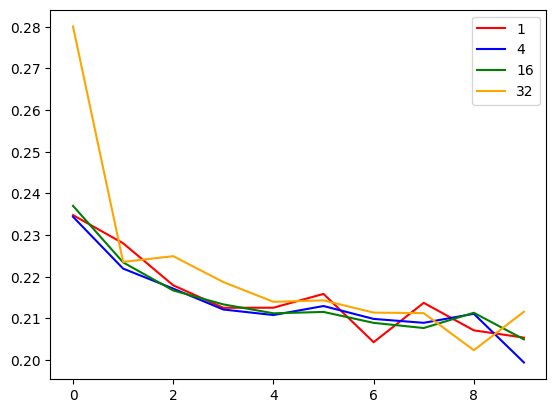

In [14]:
k1 = df[(df['n_models'] == 1) & (df['model'] == 'mssp')].sort_values('epochs')
k4 = df[df['n_models'] == 4].sort_values('epochs')
k16 = df[df['n_models'] == 16].sort_values('epochs')
k32 = df[df['n_models'] == 32].sort_values('epochs')

# x_labels = list(range(1, 11))
# x_range = list(range(10))

# plt.plot(x_range, k1['mae'].values[:11], color='red', label='1')
# plt.plot(x_range, k4['mae'].values[:11], color='blue', label='4')
# plt.plot(x_range, k16['mae'].values[:11], color='green', label='16')
# plt.plot(x_range, k32['mae'].values[:11], color='orange', label='32')
# plt.xticks(x_range, x_labels)
plt.plot(k1['mae'].values, color='red', label='1')
plt.plot(k4['mae'].values, color='blue', label='4')
plt.plot(k16['mae'].values, color='green', label='16')
plt.plot(k32['mae'].values, color='orange', label='32')
plt.legend()

In [15]:
# plt.plot(y_test, color='red')
# plt.plot(linreg_pred)

In [16]:
# rforest_model = RandomForestRegressor()
# rforest_model.fit(X_train, y_train)

In [17]:
# rforest_pred = torch.tensor(rforest_model.predict(X_test), dtype=torch.double)
# # plt.plot(inverse_transform_spy(rforest_pred, close_test)[-50:])
# # plt.plot(inverse_transform_spy(y_test, close_test)[-51:-1])
# mean_squared_error(rforest_pred, y_test)

In [18]:
# svr_model = SVR()
# svr_model.fit(X_train, y_train)
# svr_pred = torch.tensor(svr_model.predict(X_test), dtype=torch.double)
# # plt.plot(inverse_transform_spy(svr_pred, close_test)[-50:])
# # plt.plot(inverse_transform_spy(y_test, close_test)[-51:-1])
# mean_squared_error(svr_pred, y_test)

In [19]:
mssp.history

[{'type': 'primitives',
  'epoch': -1,
  'params': [(tensor([0.0060]), tensor(5.3116), 'lin', 0),
   (tensor([0.0184]), tensor(5.3295), 'lgn', 0),
   (tensor([0.0053]), tensor(1.6654), 'xpy', 0),
   (tensor([0.0042]), tensor(1.6715), 'pow', 0),
   (tensor([-4.5662e-07]), tensor(5.3156), 'rex', 0),
   (tensor([-0.0019]), tensor(0.1900), 'rey', 0),
   (tensor([0.0037]), tensor(2.3021), 'sqr', 0),
   (tensor([0.0083]), tensor(5.3107), 'snx', 0),
   (tensor([0.0095]), tensor(5.3101), 'lin', 1),
   (tensor([0.0205]), tensor(5.3325), 'lgn', 1),
   (tensor([0.0066]), tensor(1.6649), 'xpy', 1),
   (tensor([0.0046]), tensor(1.6721), 'pow', 1),
   (tensor([-4.5681e-07]), tensor(5.3156), 'rex', 1),
   (tensor([-0.0022]), tensor(0.1902), 'rey', 1),
   (tensor([0.0048]), tensor(2.3017), 'sqr', 1),
   (tensor([0.0138]), tensor(5.3084), 'snx', 1),
   (tensor([-0.4597]), tensor(5.6113), 'lin', 2),
   (tensor([0.0288]), tensor(5.3290), 'lgn', 2),
   (tensor([-0.0957]), tensor(1.7299), 'xpy', 2),
   (te

In [20]:
# for i in range(9):
    # print(len([n for n in mssp.model[0].nodes.keys() if isinstance(n, tuple) and n[0] == i]))
[n for n in mssp.model[0].nodes.items() if isinstance(n[0], tuple) and n[0][0] == 8]

[((8, tensor(5), 'lin'), <src.graph.Node at 0x1fc051b8620>),
 ((8, tensor(70), 'lin'), <src.graph.Node at 0x1fbe0d5c680>)]

<Axes: >

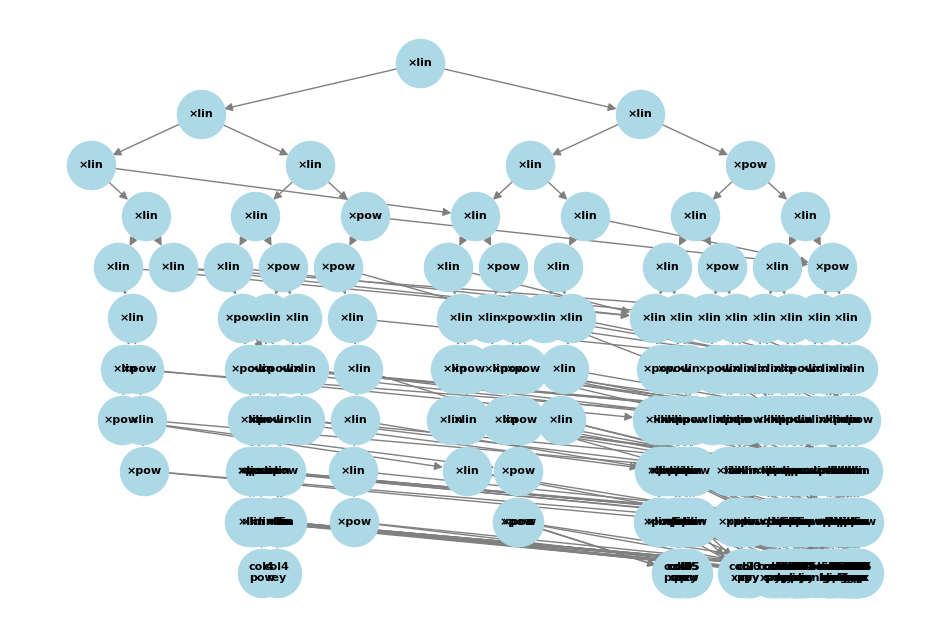

In [21]:
mssp.plot_graph(1)